In [1]:
import pandas as pd
import polars as pl
from did_multiplegt_dyn import DidMultiplegtDyn
root = '/groups/sgulzar/sa_fires/proj_bureaucrats_farms'

df = pl.read_csv(
    f'{root}/data_output/intermediate/0_master_merge_data_gen.csv',
    columns=[
        "count",
        "unique_small_grid_id",
        "monthyear",
        "year", "month",
        "downup_ac",
        "ac_uq_id",
        "av_wind_speed",
        "wind_direction",
        'province'
    ],
    ignore_errors=True,
)

In [2]:

ghs = pl.from_pandas(
    pd.read_stata(f'{root}/data_output/intermediate/ghs_grid_classification_2000.dta')
).select(['unique_small_grid_id', 'is_rural'])   # keepusing(is_rural)

df = df.join(ghs, on='unique_small_grid_id', how='inner')   # _merge == 3, drop _merge

# --- keep if is_rural == 1
df = df.filter(pl.col('is_rural') == 1)

# --- merge m:1 unique_small_grid_id using grids_with_more_1_ac.dta
#     drop if dpl_ac == 1    (then drop _merge)
grids = pl.from_pandas(
    pd.read_stata(f'{root}/data_output/intermediate/grids_with_more_1_ac.dta')
)

df = df.join(grids, on='unique_small_grid_id', how='left')   # keeps all master rows
df = df.filter((pl.col('dpl_ac') != 1) | pl.col('dpl_ac').is_null())   # drop if dpl_ac == 1

# --- keep if year < 2022 | (year == 2022 & month <= 8)
df = df.filter(
    (pl.col('year') < 2022) | ((pl.col('year') == 2022) & (pl.col('month') <= 8))
)

In [6]:
def apply_reset(
    lf: pl.LazyFrame,
    reset: int,
    group_col: str,
    treatment_col: str,
    time_col: str,
    cluster: str | None = None,
) -> tuple[pl.LazyFrame, str | None]:
    if reset == 0:
        return lf, cluster

    # -------------------------------------------------------
    # 1. Balance panel in one pass, no intermediate columns
    # -------------------------------------------------------
    lf = (
        lf.with_columns(
            pl.col(treatment_col).is_not_null()
            .cast(pl.Int8)
            .sum()
            .over(group_col)
            .alias("_count")
        )
        .filter(pl.col("_count") == pl.col("_count").max())
        .drop("_count")
        .sort([group_col, time_col])
    )

    # -------------------------------------------------------
    # 2-4. Intermediate columns
    # -------------------------------------------------------
    lf = lf.with_columns(
        pl.when(
            pl.col(time_col) == pl.col(time_col).min().over(group_col)
        )
        .then(pl.lit(0, dtype=pl.Int8))
        .when(
            pl.col(treatment_col) != pl.col(treatment_col).shift(1).over(group_col)
        )
        .then(pl.lit(1, dtype=pl.Int8))
        .otherwise(pl.lit(0, dtype=pl.Int8))
        .alias("_changed"),
    ).with_columns(
        pl.col("_changed").cum_sum().over(group_col).alias("_spell"),
    ).with_columns(
        pl.when(pl.col("_spell") == 0)
        .then(pl.lit(0, dtype=pl.Int32))
        .otherwise(
            pl.int_range(pl.len()).over([group_col, "_spell"])
        )
        .alias("_psc"),
    ).with_columns(
        (pl.col("_psc") == reset)
        .cast(pl.Int8)
        .cum_sum()
        .over(group_col)
        .alias("_rc"),
    )

    # -------------------------------------------------------
    # 5. New group: dense rank over (group, reset_count)
    # -------------------------------------------------------
    lf = lf.with_columns(
        pl.struct([group_col, "_rc"])
        .rank("dense")
        .alias(group_col)
    ).drop(["_changed", "_spell", "_psc", "_rc"])

    # -------------------------------------------------------
    # 6. Clustering default
    # -------------------------------------------------------
    if cluster is None:
        lf = lf.with_columns(
            pl.col(group_col).alias("old_group_XX")
        )
        cluster = "old_group_XX"

    return lf, cluster

In [7]:
lf, cluster = apply_reset(df.lazy(), 
                          reset=6, 
                          group_col = 'unique_small_grid_id',
                          treatment_col = 'downup_ac',
                          time_col = 'monthyear')


In [8]:
df_result = lf.collect()

In [ ]:
model1 = DidMultiplegtDyn(
    df = df_result,
    outcome = "count",
    group = "unique_small_grid_id",
    time = "monthyear",
    treatment = "downup_ac",
    effects = 6,
    placebo = 6,
    controls = ["av_wind_speed",
        "wind_direction"],
    cluster = "ac_uq_id"
)
model1.fit()
model1.summary().to_csv('/groups/sgulzar/sa_fires/dCDH_reset_year.csv', index = False)
import matplotlib.pyplot as plt
model1.plot()
plt.savefig('/groups/sgulzar/sa_fires/dCDH_reset_year.png', dpi=300, bbox_inches='tight')

In [ ]:
model1 = DidMultiplegtDyn(
    df=df,
    outcome = "count",
    group = "unique_small_grid_id",
    time = "monthyear",
    treatment = "downup_ac",
    effects = 6,
    placebo = 6,
    controls = ["av_wind_speed",
        "wind_direction"],
    cluster = "ac_uq_id",
    trends_nonparam = ['province']
)
model1.fit()
model1.summary().to_csv('/groups/sgulzar/sa_fires/dCDH_prov_year.csv', index = False)
import matplotlib.pyplot as plt
model1.plot()
plt.savefig('/groups/sgulzar/sa_fires/dCDH_prov_year.png', dpi=300, bbox_inches='tight')

/groups/sgulzar/india_forest_land/did_stat/lib/python3.10/site-packages/did_multiplegt_dyn/did_multiplegt_main.py:3531: UserWarning: The F-test may not be reliable, because the variance of effects is close to not being invertible (the ratio of its largest and smallest eigenvalues is 1165.7, which is larger than 1000). This can for instance happen when you compute many estimators, or when your estimates are very strongly correlated. We recommend that you complement the F-test with a sup t-test, see FAQ section of the help file for more details.
  warnings.warn(matrix_warning, UserWarning)
/groups/sgulzar/india_forest_land/did_stat/lib/python3.10/site-packages/did_multiplegt_dyn/did_multiplegt_main.py:3662: UserWarning: The F-test may not be reliable, because the variance of placebos is close to not being invertible (the ratio of its largest and smallest eigenvalues is 180583.1, which is larger than 1000). This can for instance happen when you compute many estimators, or when your estima

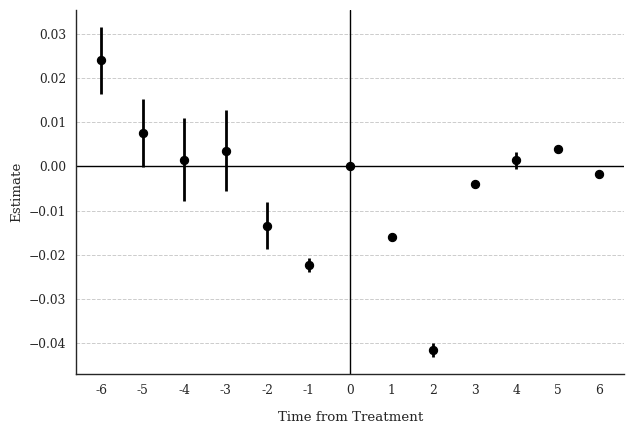

In [3]:
model1 = DidMultiplegtDyn(
    df=df,
    outcome = "count",
    group = "unique_small_grid_id",
    time = "monthyear",
    treatment = "downup_ac",
    effects = 6,
    placebo = 6,
    controls = ["av_wind_speed",
        "wind_direction"],
    cluster = "ac_uq_id",
    trends_nonparam = ['ac_uq_id']
)
model1.fit()
model1.summary().to_csv('/groups/sgulzar/sa_fires/dCDH_ac_year.csv', index = False)
import matplotlib.pyplot as plt
model1.plot()
plt.savefig('/groups/sgulzar/sa_fires/dCDH_ac_year.png', dpi=300, bbox_inches='tight')

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI         N  Switchers       N.w  Switchers.w
            Effect_1 -0.015868 0.000251 -0.016361 -0.015375  299728.0    57847.0  299728.0      57847.0
            Effect_2 -0.041527 0.000798 -0.043092 -0.039962  277983.0    55586.0  277983.0      55586.0
            Effect_3 -0.003986 0.000411 -0.004792 -0.003180  258635.0    54666.0  258635.0      54666.0
            Effect_4  0.001415 0.000976 -0.000499  0.003329  249943.0    54163.0  249943.0      54163.0
            Effect_5  0.003974 0.000311  0.003365  0.004584  241913.0    53828.0  241913.0      53828.0
            Effect_6 -0.001708 0.000386 -0.002465 -0.000951  233125.0    53736.0  233125.0      53736.0
Average_Total_Effect -0.018705 0.000720 -0.020117 -0.017294 1080919.0   329826.0 1080919.0     329826.0
           Placebo_1 -0.022311 0.000801 -0.023882 -0.020740  227302.0    40641.0  227302.0      40641.

In [3]:
model1 = DidMultiplegtDyn(
    df=df,
    outcome = "count",
    group = "unique_small_grid_id",
    time = "monthyear",
    treatment = "downup_ac",
    effects = 6,
    placebo = 6,
    controls = ["av_wind_speed",
        "wind_direction"],
    cluster = "ac_uq_id"
)
model1.fit()

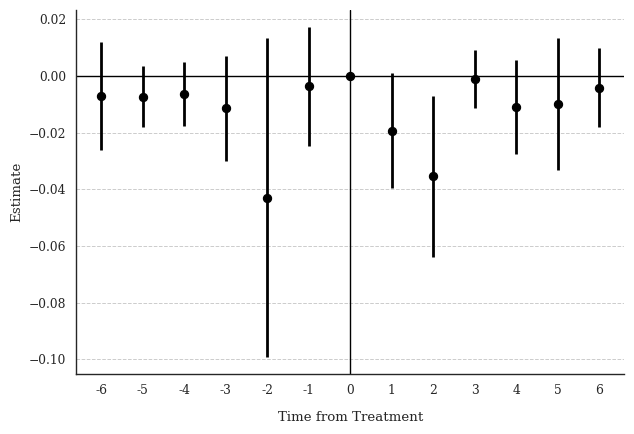

In [10]:
import matplotlib.pyplot as plt
model1.plot()
plt.savefig('/groups/sgulzar/sa_fires/dCDH_nocontrols.png', dpi=300, bbox_inches='tight')

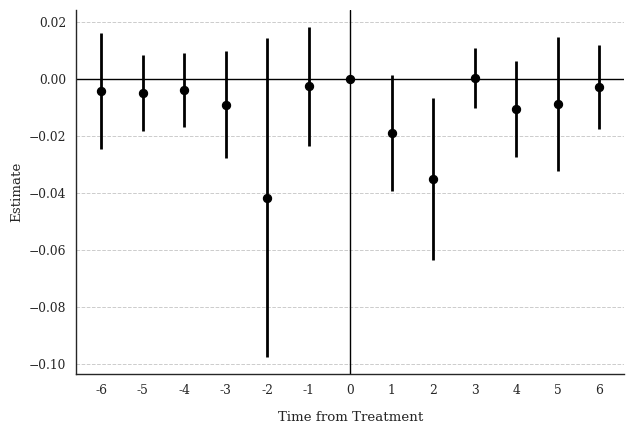

In [3]:
model1 = DidMultiplegtDyn(
    df=df,
    outcome = "count",
    group = "unique_small_grid_id",
    time = "monthyear",
    treatment = "downup_ac",
    effects = 6,
    placebo = 6,
    controls = ["av_wind_speed",
        "wind_direction"],
    cluster = "ac_uq_id"
)
model1.fit()
import matplotlib.pyplot as plt
model1.plot()
plt.savefig('/groups/sgulzar/sa_fires/dCDH_regularcontrols.png', dpi=300, bbox_inches='tight')

In [4]:
import pandas as pd
import polars as pl
from did_multiplegt_dyn import DidMultiplegtDyn
root = '/groups/sgulzar/sa_fires/proj_bureaucrats_farms'

df = pl.read_csv(
    f'{root}/data_output/intermediate/0_master_merge_data_gen.csv',
    columns=[
        "count",
        "unique_small_grid_id",
        "monthyear",
        "year", "month",
        "downup_ac",
        "ac_uq_id",
        "av_wind_speed",
        "wind_direction"
    ],
    ignore_errors=True,
)

ghs = pl.from_pandas(
    pd.read_stata(f'{root}/data_output/intermediate/ghs_grid_classification_2000.dta')
).select(['unique_small_grid_id', 'is_rural'])   # keepusing(is_rural)

df = df.join(ghs, on='unique_small_grid_id', how='inner')   # _merge == 3, drop _merge

# --- keep if is_rural == 1
df = df.filter(pl.col('is_rural') == 1)

# --- merge m:1 unique_small_grid_id using grids_with_more_1_ac.dta
#     drop if dpl_ac == 1    (then drop _merge)
grids = pl.from_pandas(
    pd.read_stata(f'{root}/data_output/intermediate/grids_with_more_1_ac.dta')
)

df = df.join(grids, on='unique_small_grid_id', how='left')   # keeps all master rows
df = df.filter((pl.col('dpl_ac') != 1) | pl.col('dpl_ac').is_null())   # drop if dpl_ac == 1

# --- keep if year < 2022 | (year == 2022 & month <= 8)
df = df.filter(
    (pl.col('year') < 2022) | ((pl.col('year') == 2022) & (pl.col('month') <= 8))
)


df = df.with_columns(
    (pl.col("ac_uq_id").cast(pl.Utf8) + "_" + pl.col("monthyear").cast(pl.Utf8))
    .alias("ac_x_my")
)

df = df.to_dummies(columns=["ac_x_my"])   # creates ac_x_my_<value> columns

# --- collect the generated dummy column names ---
interaction_cols = [c for c in df.columns if c.startswith("ac_x_my_")]

# --- to avoid perfect collinearity, drop one dummy (the reference category) ---
interaction_cols = interaction_cols[1:]

# --- combine with your existing controls ---
controls = ["av_wind_speed", "wind_direction"] + interaction_cols

In [ ]:
model1 = DidMultiplegtDyn(
    df=df,
    outcome = "count",
    group = "unique_small_grid_id",
    time = "monthyear",
    treatment = "downup_ac",
    effects = 6,
    placebo = 6,
    controls = controls,
    cluster = "ac_uq_id"
)
model1.fit()
import matplotlib.pyplot as plt
model1.plot()
plt.savefig('/groups/sgulzar/sa_fires/dCDH_regularcontrols_fe.png', dpi=300, bbox_inches='tight')